In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


In [70]:
%matplotlib inline

In [71]:
iris = datasets.load_iris()
lf_x = pl.LazyFrame(iris["data"], schema=iris["feature_names"])
# print(lf_x.collect())
print("target_names:", iris["target_names"])
lf_y = pl.LazyFrame(iris["target"], schema=["target"])
# print(lf_y.collect())
lf_iris = (
    pl.concat([lf_x, lf_y], how="horizontal")
    .select(["sepal length (cm)", "petal length (cm)", "target"])
    .filter(pl.col("target").is_in([0, 1]))
)
lf_iris.collect()

target_names: ['setosa' 'versicolor' 'virginica']


sepal length (cm),petal length (cm),target
f64,f64,i64
5.1,1.4,0
4.9,1.4,0
4.7,1.3,0
4.6,1.5,0
5.0,1.4,0
…,…,…
5.7,4.2,1
5.7,4.2,1
6.2,4.3,1


In [72]:
x_train, x_test, y_train, y_test = train_test_split(
    lf_iris.select(["sepal length (cm)", "petal length (cm)"]).collect(),
    lf_iris.select(["target"]).collect(),
    test_size=0.3,
    random_state=0,
)

In [73]:
x_train

sepal length (cm),petal length (cm)
f64,f64
5.0,3.5
5.5,3.8
5.5,4.4
6.2,4.5
6.4,4.5
…,…
5.7,4.2
5.8,4.1
5.6,3.6


In [74]:
x_test

sepal length (cm),petal length (cm)
f64,f64
5.0,1.6
6.7,4.7
4.7,1.3
5.7,4.5
6.6,4.4
…,…
5.3,1.5
4.6,1.4
5.7,4.1


In [75]:
sc = StandardScaler()
sc.fit(x_train)
x_train_std = sc.transform(x_train)
x_test_std = sc.transform(x_test)

In [76]:
x_train_std

array([[-0.80800774,  0.43666598],
       [ 0.01648995,  0.64460217],
       [ 0.01648995,  1.06047453],
       [ 1.17078673,  1.12978659],
       [ 1.50058581,  1.12978659],
       [-0.47820866, -0.94957523],
       [ 0.34628903, -0.81095111],
       [ 1.33568627,  1.26841071],
       [ 1.00588719,  1.26841071],
       [ 1.50058581,  0.99116247],
       [-0.97290728, -1.01888729],
       [ 0.67608811,  0.92185041],
       [-1.79740498, -1.08819936],
       [-1.63250544, -1.08819936],
       [-0.80800774, -1.01888729],
       [ 0.34628903, -0.94957523],
       [-0.6431082 , -1.01888729],
       [-0.80800774, -1.08819936],
       [-1.79740498, -1.08819936],
       [-0.14840959, -0.81095111],
       [ 1.00588719,  1.19909865],
       [-0.47820866,  0.71391423],
       [-0.6431082 , -1.01888729],
       [-0.97290728, -0.94957523],
       [-0.47820866, -1.01888729],
       [ 2.48998304,  1.26841071],
       [-1.13780682, -0.88026317],
       [-0.80800774, -1.15751142],
       [-0.6431082 ,

In [77]:
svm = SVC(kernel="linear", probability=True)

In [78]:
svm.fit(x_train_std, y_train.select("target").to_numpy().flatten())

SVC(kernel='linear', probability=True)

In [79]:
svm.predict(x_test_std)

array([0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1])

In [80]:
y_test.select("target").to_numpy().flatten()

array([0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1])

In [81]:
# 1. 先把預測結果與真實答案轉成 NumPy 陣列
y_pred = svm.predict(x_test_std)
y_true = y_test.select("target").to_numpy().flatten()

# 2. 計算錯誤數
error = np.sum(y_pred != y_true)
print(error)

0


In [82]:
svm.predict_proba(x_test_std)

array([[0.9503827 , 0.0496173 ],
       [0.00918226, 0.99081774],
       [0.97376236, 0.02623764],
       [0.00795019, 0.99204981],
       [0.0199866 , 0.9800134 ],
       [0.13151622, 0.86848378],
       [0.98410913, 0.01589087],
       [0.00598328, 0.99401672],
       [0.01057988, 0.98942012],
       [0.01859892, 0.98140108],
       [0.02830323, 0.97169677],
       [0.03487491, 0.96512509],
       [0.00984574, 0.99015426],
       [0.98026564, 0.01973436],
       [0.96258391, 0.03741609],
       [0.94290559, 0.05709441],
       [0.98804942, 0.01195058],
       [0.87946655, 0.12053345],
       [0.98030928, 0.01969072],
       [0.95685247, 0.04314753],
       [0.9503827 , 0.0496173 ],
       [0.04004828, 0.95995172],
       [0.95034671, 0.04965329],
       [0.04290323, 0.95709677],
       [0.96752232, 0.03247768],
       [0.96977914, 0.03022086],
       [0.96255653, 0.03744347],
       [0.02462469, 0.97537531],
       [0.0459194 , 0.9540806 ],
       [0.00741891, 0.99258109]])

In [83]:
def plot_decision_regions(x, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ("s", "x", "o", "^", "v")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[: len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    x2_min, x2_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)
    )

    z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    z = z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=x[y == cl, 0],
            y=x[y == cl, 1],
            alpha=0.6,
            c=cmap(idx),
            edgecolors="black",
            marker=markers[idx],
            label=cl,
        )

    # highlight test samples
    if test_idx:
        # plot all samples
        if not str(np.version.version) >= "1.9.0":
            x_test, y_test = x[list(test_idx), :], y[list(test_idx)]
            warnings.warn("Please update to NumPy 1.9.0 or newer")
        else:
            X_test, y_test = x[test_idx, :], y[test_idx]
        plt.scatter(
            x_test[:, 0],
            x_test[:, 1],
            alpha=1.0,
            c="",
            edgecolors="black",
            marker="o",
            label="test test",
            s=55,
        )

C:\Users\User\AppData\Local\Temp\ipykernel_23896\1923288742.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(
C:\Users\User\AppData\Local\Temp\ipykernel_23896\1923288742.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


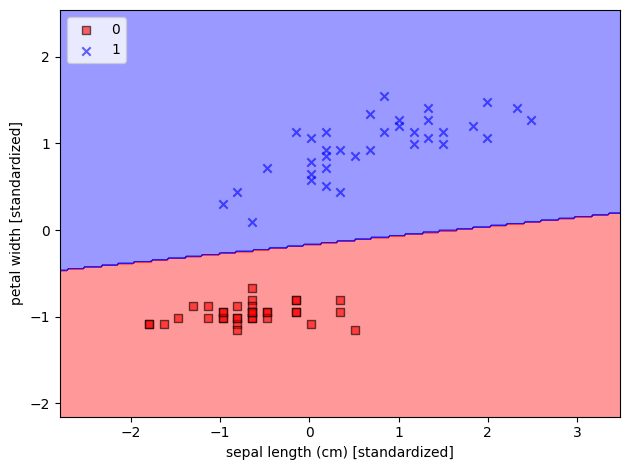

: 

In [ ]:
plot_decision_regions(
    x_train_std, y_train.select("target").to_numpy().flatten(), classifier=svm
)
plt.xlabel("sepal length (cm) [standardized]")
plt.ylabel("petal width [standardized]")
plt.legend(loc="upper left")
plt.tight_layout()